In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import KFold

from torch.utils.data import DataLoader, Subset

from vit import VisionTransformer
from tqdm.notebook import tqdm

In [2]:
# Download and load training and test sets
trainset = torchvision.datasets.CIFAR10(root='/Users/ahad/Library/Projects/Papers-From-Scratch/Datasets/cifar10', train=True, download=False)
testset = torchvision.datasets.CIFAR10(root='/Users/ahad/Library/Projects/Papers-From-Scratch/Datasets/cifar10', train=False, download=False)


In [3]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    """Check if GPU is available and return the appropriate device for MPS, CUDA, or CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    else:
        return torch.device("cpu")

In [4]:
set_seed(0)
DEVICE = get_device()

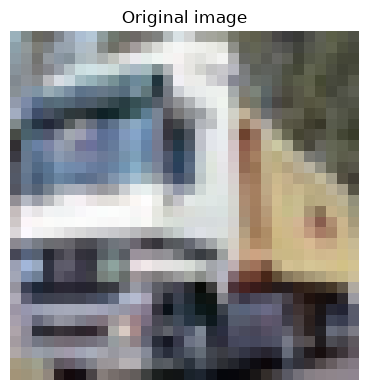

Shape: (32, 32, 3)


In [5]:
img = np.array(trainset[1][0])  # shape: (H, W, C), dtype: uint8

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Original image")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Shape: {img.shape}")

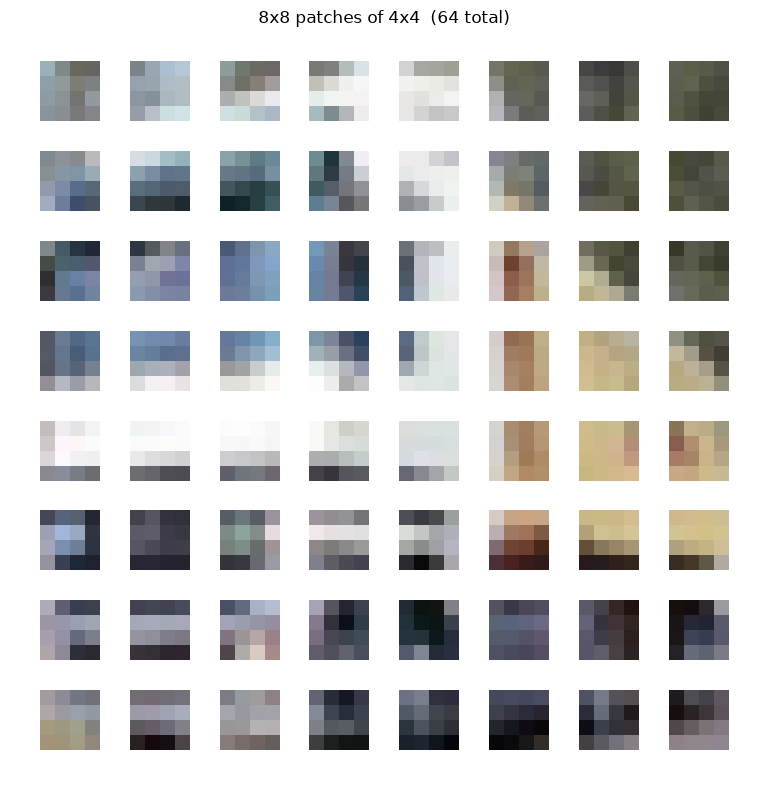

In [6]:
PATCH_SIZE = 4

H, W, C = img.shape
assert H % PATCH_SIZE == 0 and W % PATCH_SIZE == 0

n_rows = H // PATCH_SIZE
n_cols = W // PATCH_SIZE
gap = 2  # white border between patches (pixels)

grid_h = n_rows * PATCH_SIZE + (n_rows + 1) * gap
grid_w = n_cols * PATCH_SIZE + (n_cols + 1) * gap
grid = np.full((grid_h, grid_w, 3), 255, dtype=np.uint8)

for i in range(n_rows):
    for j in range(n_cols):
        y = gap + i * (PATCH_SIZE + gap)
        x = gap + j * (PATCH_SIZE + gap)
        grid[y : y + PATCH_SIZE, x : x + PATCH_SIZE] = img[
            i * PATCH_SIZE : (i + 1) * PATCH_SIZE,
            j * PATCH_SIZE : (j + 1) * PATCH_SIZE,
        ]

plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.title(f"{n_rows}x{n_cols} patches of {PATCH_SIZE}x{PATCH_SIZE}  ({n_rows * n_cols} total)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Normalizing the data to be used for training

In [7]:
mean, std = trainset.data.mean(axis=(0, 1, 2), keepdims=True) / 255.0, trainset.data.std(axis=(0, 1, 2), keepdims=True) / 255.0

trainset.data = (trainset.data - mean) / std
testset.data = (testset.data - mean) / std

In [8]:
mean, std

(array([[[[0.49139968, 0.48215841, 0.44653091]]]]),
 array([[[[0.24703223, 0.24348513, 0.26158784]]]]))

In [9]:
trainset.data = (trainset.data - mean)/std
testset.data = (testset.data - mean)/std

trainset.transforms = transforms.ToTensor()
testset.transforms = transforms.ToTensor()

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.squeeze().tolist(), std=std.squeeze().tolist())
])

In [11]:
# Download and load training and test sets
trainset = torchvision.datasets.CIFAR10(root='/Users/ahad/Library/Projects/Papers-From-Scratch/Datasets/cifar10', train=True, download=False, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/Users/ahad/Library/Projects/Papers-From-Scratch/Datasets/cifar10', train=False, download=False, transform=transform)


In [ ]:
batch_size = 256
epochs = 10
kfold_splits = 3

lr = 1e-3
early_stopping_patience = 3

params = dict(
        img_size= trainset.data.shape[1],  # Assuming square images, use height as img_size
        patch_size= 4,
        in_channels= 3,
        num_classes= trainset.classes.__len__(),
        embed_dim= 256,
        depth= 5,
        num_heads= 8,
        mlp_ratio= 4,
)




In [25]:
VisionTransformer(**params)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (transformer_blocks): ModuleList(
    (0-4): 5 x TransformerBlock(
      (layernorm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (mhsa): MultiHeadAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
      )
      (layernorm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1024, out_features=256, bias=True)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [26]:
class Tracker:
      def __init__(self):
          self.history = {}  # fold -> list of epoch dicts

      def log(self, fold, epoch, train_loss, val_loss, train_acc, val_acc):
          self.history.setdefault(fold, []).append({
              "epoch": epoch,
              "train_loss": train_loss,
              "val_loss": val_loss,
              "train_acc": train_acc,
              "val_acc": val_acc,
          })

      def summary(self):
          for fold, epochs in self.history.items():
              last = epochs[-1]
              print(f"Fold {fold} | val_loss={last['val_loss']:.4f} | val_acc={last['val_acc']:.4f}")

In [28]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

tracker = Tracker()

for fold, (train_idx, val_idx) in tqdm(enumerate(kfold.split(trainset)), total=kfold.get_n_splits()):
    print(f"Fold {fold + 1}/{kfold.get_n_splits()}")
    train_subset = Subset(trainset, train_idx)
    val_subset = Subset(trainset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = VisionTransformer(**params).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    

    print(f"Model Created, Training on {len(train_subset)} samples, validating on {len(val_subset)} samples.")

    # Training loop for the current fold
    for epoch in tqdm(range(epochs), desc=f"Fold {fold + 1}", leave=False):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", leave=False)

        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

            pbar.set_postfix(loss=loss.item(), train_acc=train_correct / train_total)

        lr_scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Validation Epoch {epoch + 1}/{epochs}", leave=False)
            for images, labels in pbar_val:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item() * images.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += labels.size(0)

                pbar_val.set_postfix(loss=val_loss / val_total, val_acc=val_correct / val_total)

        tracker.log(fold=fold + 1, epoch=epoch + 1,
                    train_loss=train_loss / train_total,
                    val_loss=val_loss / val_total,
                    train_acc=train_correct / train_total,
                    val_acc=val_correct / val_total)

        print(
            f"Fold {fold+1} | Epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss/len(train_loader):.4f} train_acc={train_correct/train_total:.4f} | "
            f"val_loss={val_loss/len(val_loader):.4f} val_acc={val_correct/val_total:.4f}"
  )

  0%|          | 0/3 [00:00<?, ?it/s]

Fold 1/3
Model Created, Training on 33333 samples, validating on 16667 samples.


Fold 1:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/131 [00:00<?, ?it/s]

Validation Epoch 1/10:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation Epoch 9/10:   0%|          | 0/66 [00:00<?, ?it/s]

Fold 3 | Epoch 9/10 | train_loss=182.6950 train_acc=0.7422 | val_loss=279.5164 val_acc=0.6258


Epoch 10/10:   0%|          | 0/131 [00:00<?, ?it/s]

Validation Epoch 10/10:   0%|          | 0/66 [00:00<?, ?it/s]

Fold 3 | Epoch 10/10 | train_loss=161.1687 train_acc=0.7769 | val_loss=281.1701 val_acc=0.6270


In [ ]:
tracker.summary()

Fold 1 | val_loss=1.1076 | val_acc=0.6267
Fold 2 | val_loss=1.1505 | val_acc=0.6180
Fold 3 | val_loss=1.1135 | val_acc=0.6270


In [30]:
## Total time taken for training and validation across all folds 39 mins 54 secs

In [32]:
# Total learnable parameters in the model
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total learnable parameters: {total_params}")

Total learnable parameters: 3981322


In [34]:
# Testing the model on the test set

test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

val_loss, val_correct, val_total = 0, 0, 0
with torch.no_grad():
    pbar_val = tqdm(test_loader, desc=f"Validation Epoch {epoch + 1}/{epochs}", leave=False)
    for images, labels in pbar_val:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        val_loss += criterion(outputs, labels).item() * images.size(0)
        val_correct += (outputs.argmax(dim=1) == labels).sum().item()
        val_total += labels.size(0)

        pbar_val.set_postfix(loss=val_loss / val_total, val_acc=val_correct / val_total)


Validation Epoch 10/10:   0%|          | 0/40 [00:00<?, ?it/s]

In [35]:
val_correct / val_total

0.6244

In [47]:
# Save the Vision Transformer model
model_save_path = Path("../Outputs/vision_transformer_model.pth")
torch.save(model.state_dict(), model_save_path) 

In [38]:
from cnn import CNN

In [48]:
params_cnn = dict(
    in_channels = 3, 
    num_classes = 10, 
    hidden_dim = 128, 
    kernel_size = 3, 
    stride = 1, 
    padding = 1, 
    conv1_out_channels= 32, 
    conv2_out_channels= 64
)

In [49]:
CNN(**params_cnn)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [50]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

tracker = Tracker()

for fold, (train_idx, val_idx) in tqdm(enumerate(kfold.split(trainset)), total=kfold.get_n_splits()):
    print(f"Fold {fold + 1}/{kfold.get_n_splits()}")
    train_subset = Subset(trainset, train_idx)
    val_subset = Subset(trainset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CNN(**params_cnn).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    

    print(f"Model Created, Training on {len(train_subset)} samples, validating on {len(val_subset)} samples.")

    # Training loop for the current fold
    for epoch in tqdm(range(epochs), desc=f"Fold {fold + 1}", leave=False):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}", leave=False)

        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

            pbar.set_postfix(loss=loss.item(), train_acc=train_correct / train_total)

        lr_scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            pbar_val = tqdm(val_loader, desc=f"Validation Epoch {epoch + 1}/{epochs}", leave=False)
            for images, labels in pbar_val:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item() * images.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += labels.size(0)

                pbar_val.set_postfix(loss=val_loss / val_total, val_acc=val_correct / val_total)

        tracker.log(fold=fold + 1, epoch=epoch + 1,
                    train_loss=train_loss / train_total,
                    val_loss=val_loss / val_total,
                    train_acc=train_correct / train_total,
                    val_acc=val_correct / val_total)

        print(
            f"Fold {fold+1} | Epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss/len(train_loader):.4f} train_acc={train_correct/train_total:.4f} | "
            f"val_loss={val_loss/len(val_loader):.4f} val_acc={val_correct/val_total:.4f}"
  )

  0%|          | 0/3 [00:00<?, ?it/s]

Fold 1/3
Model Created, Training on 33333 samples, validating on 16667 samples.


Fold 1:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/131 [00:00<?, ?it/s]

Validation Epoch 1/10:   0%|          | 0/66 [00:00<?, ?it/s]

...

Validation Epoch 9/10:   0%|          | 0/66 [00:00<?, ?it/s]

Fold 3 | Epoch 9/10 | train_loss=162.3413 train_acc=0.7854 | val_loss=221.8312 val_acc=0.7008


Epoch 10/10:   0%|          | 0/131 [00:00<?, ?it/s]

Validation Epoch 10/10:   0%|          | 0/66 [00:00<?, ?it/s]

Fold 3 | Epoch 10/10 | train_loss=157.1613 train_acc=0.7937 | val_loss=220.9338 val_acc=0.7011


In [51]:
# Save the Vision Transformer model
model_save_path = Path("../Outputs/cnn_model.pth")
torch.save(model.state_dict(), model_save_path) 

In [52]:
# Total learnable parameters in the model
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total learnable parameters: {total_params}")

Total learnable parameters: 545098


In [53]:
# Testing the model on the test set

test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

val_loss, val_correct, val_total = 0, 0, 0
with torch.no_grad():
    pbar_val = tqdm(test_loader, desc=f"Validation Epoch {epoch + 1}/{epochs}", leave=False)
    for images, labels in pbar_val:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        val_loss += criterion(outputs, labels).item() * images.size(0)
        val_correct += (outputs.argmax(dim=1) == labels).sum().item()
        val_total += labels.size(0)

        pbar_val.set_postfix(loss=val_loss / val_total, val_acc=val_correct / val_total)


Validation Epoch 10/10:   0%|          | 0/40 [00:00<?, ?it/s]

In [54]:
val_correct / val_total

0.7014